# Step 2 Word Cloud for EPB Abstract Each Decade and All

In [1]:
#regular packages
import pandas as pd
import string
import os
#nlp packages
import nltk
import contractions
from nltk.corpus import stopwords
#nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *

In [2]:
#import nltk
#nltk.download('punkt')
#nltk.download('stopwords')
#import ssl

#try:
#    _create_unverified_https_context = ssl._create_unverified_context
#except AttributeError:
#    pass
#else:
#    ssl._create_default_https_context = _create_unverified_https_context#

#nltk.download()

# 0 Load Data
## 0.1 Individual decade

In [3]:
df70 = pd.read_csv('data_papers/1970s.csv')
df80 = pd.read_csv('data_papers/1980s.csv')
df90 = pd.read_csv('data_papers/1990s.csv')
df00 = pd.read_csv('data_papers/2000s.csv')
df10 = pd.read_csv('data_papers/2010s.csv')
df20 = pd.read_csv('data_papers/2020s.csv')

df_inpress = pd.read_csv('data_papers/inpress.csv')
df_data = pd.read_csv('data_papers/EPB_Data.csv')
df_fg = pd.read_csv('data_papers/EPB_FG.csv')

In [4]:
df_20 = pd.concat([df20, df_inpress, df_data, df_fg],  ignore_index=True)

In [5]:
directory_path = 'data_papers'
# List all files in the directory
files = os.listdir(directory_path)

# Filter out only CSV files
csv_files = [file for file in files if file.endswith('.csv')]

full_df = pd.DataFrame()
# Iterate through each CSV file and read it using pandas
for csv_file in csv_files:
    file_path = os.path.join(directory_path, csv_file)
    df = pd.read_csv(file_path)
    full_df = pd.concat([full_df, df])
    
    # Now you can work with the dataframe 'df'
    # For example, print the first few rows
    print(f"Contents of {csv_file}:")
print(len(full_df))
#print(full_df.head())    

Contents of 2020s.csv:
Contents of 2000s.csv:
Contents of 1990s.csv:
Contents of 2010s.csv:
Contents of inpress.csv:
Contents of EPB_FG.csv:
Contents of 1980s.csv:
Contents of EPB_Data.csv:
Contents of 1970s.csv:
2566


In [6]:
rows_with_nan = full_df[full_df["Abstract Note"] == 'nan']
rows_with_nan

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Programming Language,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body


## 1 Preprocessing: Cleaning Text 

### 1.1 Removing stop words along with other words
* remove the words shows uo more than 1000 time 
* remove meaingless words 

In [7]:
regular_stop_words = stopwords.words('english')

In [8]:
words_1k = ['urban', 'model', 'city', 'planning', 'study', 'data', 'spatial', 'use', 'area', 'based', 'paper', 'system']
words_other = ['result', 'ha', 'method', 'approach', 'using', 'different', 'new', 'used', 'level', 'research', 'two', 'information', 'wa', 'also', 'problem', 'effect'
                'type', 'show', 'case', 'impact', 'within', 'however', 'developed', 'application', 'high', 'context', 'relationship', 'may', 'potential', 'characteristic', 'finding', 'term', 'well', 'value', 'first', 'present', 'number', 'large', 'distribution', "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "finding", "built"]

additional_words = ['provide', 'technique', 'important', 'various', 'existing', 'way', 'applied', 'understanding', 'significant', 'need', 'future', 'many', 'size', 'found', 'across', 'higher', 'function', 'identify', 'presented']
                    #'time', 'issue', 'made', 'user', 'work', 'author', 'mean', 'map']#, 'article'

epb_stop_words = regular_stop_words + words_1k + words_other + additional_words

## 1.2 Full Test Cleaning

In [9]:
from src.preprocessing import __general_preprocess__
from src.preprocessing import __remove_plurals__
from src.preprocessing import __remove_stopwords__
from src.preprocessing import __get_word_freq__

In [10]:
full_df['Abstract Note'] = full_df['Abstract Note'].astype(str)
full_df['abstract'] = __general_preprocess__(full_df['Abstract Note'])
full_df['abstract'] = full_df['abstract'].apply(lambda x: __remove_plurals__(x))
full_df['abstract'] = __remove_stopwords__(full_df['abstract'], epb_stop_words)
full_freq = __get_word_freq__(full_df['abstract'])

In [11]:
full_freq

land             1351
design           1332
analysis         1284
development      1273
space            1026
                 ... 
bangladeshi         1
underperforms       1
thresholding        1
imaging             1
catering            1
Name: count, Length: 12853, dtype: int64

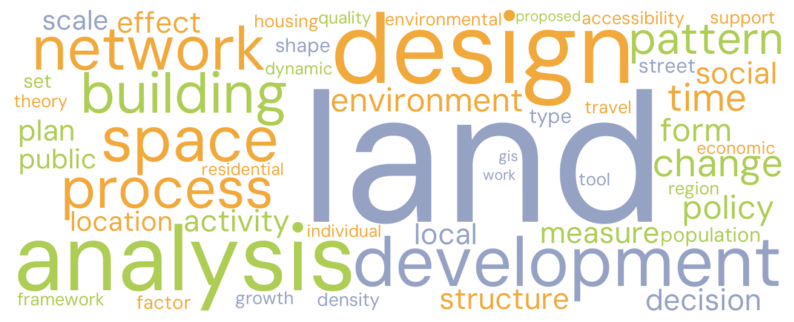

In [14]:
from src.analysistools import __gen_cloud_3_color__
__gen_cloud_3_color__(full_freq[:50], 1280, 500)

# 2, Word Cloud for Each decade 
## 2.1 1970s 

In [14]:
from src.preprocessing import __decade_pre_process__

In [16]:
df70_freq = __decade_pre_process__(df70, epb_stop_words)
df70_freq

design            66
building          42
set               40
space             38
theory            34
                  ..
overconstraint     1
normally           1
list               1
bar                1
intersection       1
Name: count, Length: 1651, dtype: int64

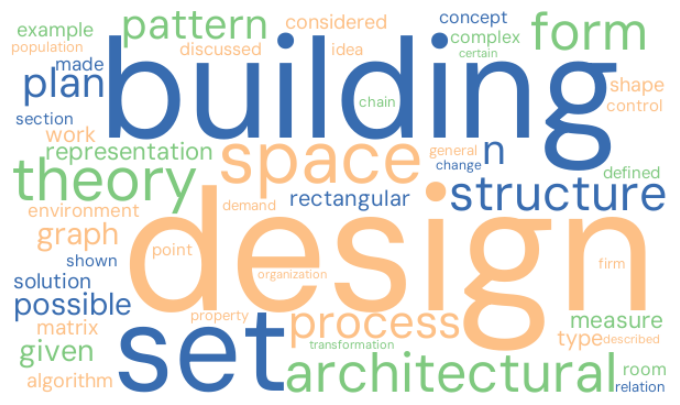

In [21]:
__gen_cloud_3_color__(df70_freq[:50], 600, 350)

## 2.2 1980s 

In [18]:
df80_freq = __decade_pre_process__(df80, epb_stop_words)
df80_freq

design           182
development      117
analysis         112
structure         96
plan              90
                ... 
net                1
saved              1
invoke             1
tier               1
voluntaristic      1
Name: count, Length: 3683, dtype: int64

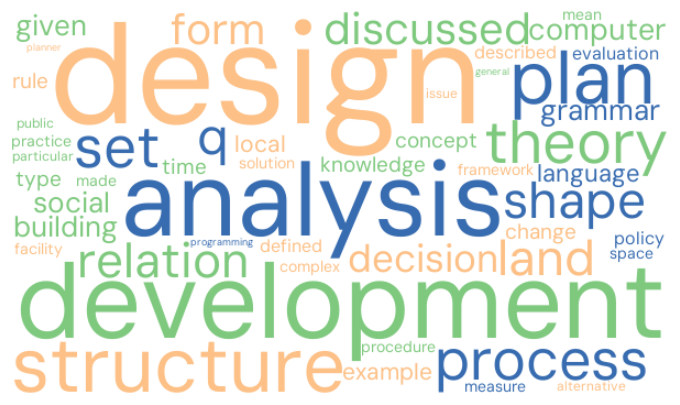

In [32]:
__gen_cloud_3_color__(df80_freq[:50], 600, 350)

## 2.3 1990s 

In [33]:
df90_freq = __decade_pre_process__(df90, epb_stop_words)
df90_freq

design         318
development    206
land           158
analysis       146
process        145
              ... 
naples           1
arisen           1
log              1
reproduce        1
dual             1
Name: count, Length: 5067, dtype: int64

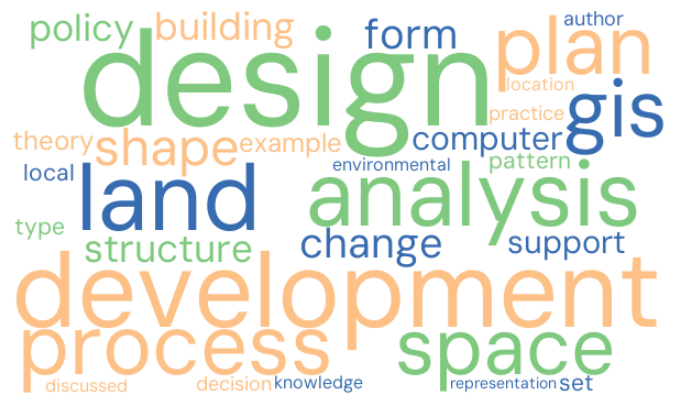

In [38]:
__gen_cloud_3_color__(df90_freq[:30], 600, 350)

## 2.4 2000s 

In [39]:
df00_freq = __decade_pre_process__(df00, epb_stop_words)
df00_freq

land            336
development     286
analysis        273
design          224
space           207
               ... 
universally       1
sweep             1
durham            1
warwick           1
occupational      1
Name: count, Length: 6078, dtype: int64

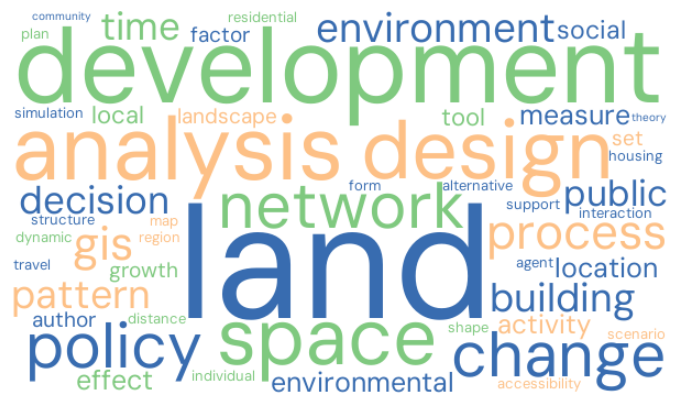

In [43]:
__gen_cloud_3_color__(df00_freq[:50],600,350)

## 2.5 2010s 

In [44]:
df10_freq = __decade_pre_process__(df10, epb_stop_words)
df10_freq

land           452
development    356
analysis       344
design         323
network        322
              ... 
elude            1
typo             1
burgage          1
adaption         1
gave             1
Name: count, Length: 6805, dtype: int64

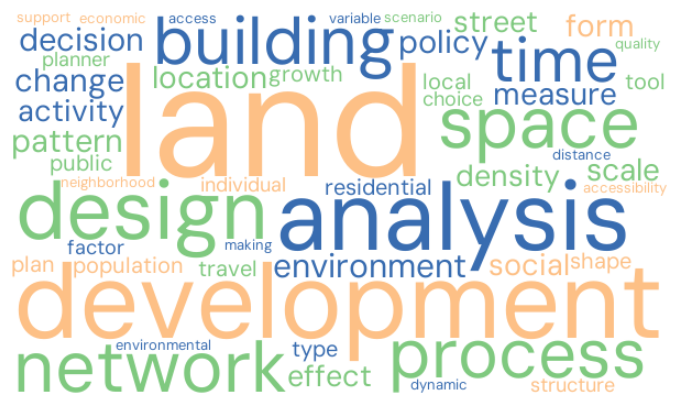

In [52]:
__gen_cloud_3_color__(df10_freq[:50],600,350)

## 2.6 2020s 

In [53]:
df20_freq = __decade_pre_process__(df20, epb_stop_words)
df20_freq

analysis       346
network        321
land           302
development    263
space          258
              ... 
mumbai           1
expressive       1
subsidize        1
slice            1
medoids          1
Name: count, Length: 6769, dtype: int64

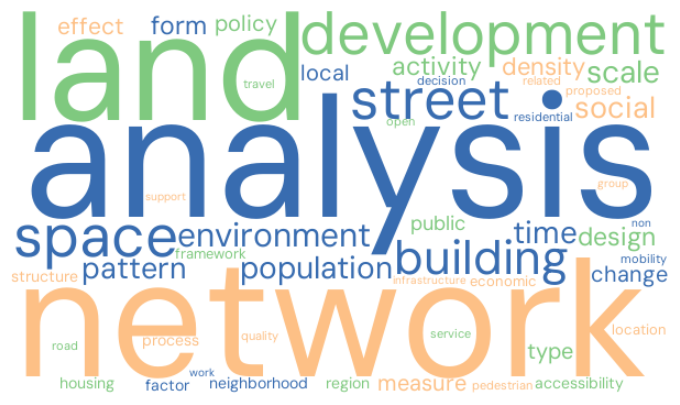

In [65]:
__gen_cloud_3_color__(df20_freq[:50], 600, 350)